# Student Stress Classification

Machine Learning Assignment - Part E

Dataset: Student Stress Survey (843 college students, ages 18-21)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, silhouette_score
import scipy.cluster.hierarchy as shc

(843, 25)
   gender  age  stress_experienced  heart_palpitations  anxiety  \
0       0   20                   3                   4        2   
1       0   20                   2                   3        2   
2       0   20                   5                   4        2   
3       1   20                   3                   4        3   
4       0   20                   3                   3        3   
5       0   20                   3                   4        3   
6       0   20                   2                   2        1   

   sleep_problems  headaches  irritability  concentration_issues  sadness  \
0               5          2             1                     2        2   
1               1          1             1                     4        2   
2               2          3             4                     2        3   
3               2          3             4                     3        5   
4               2          4             4                     4    

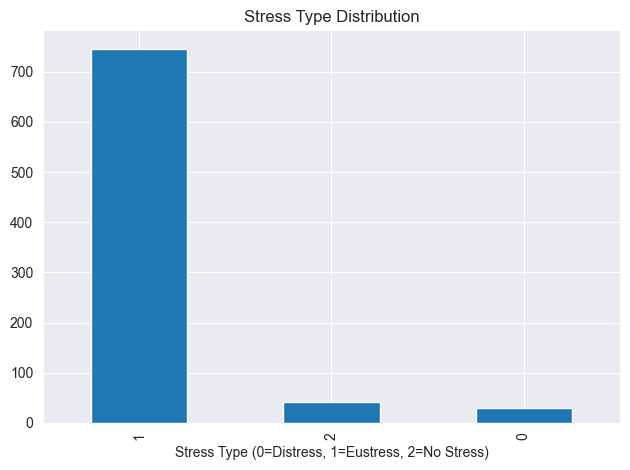

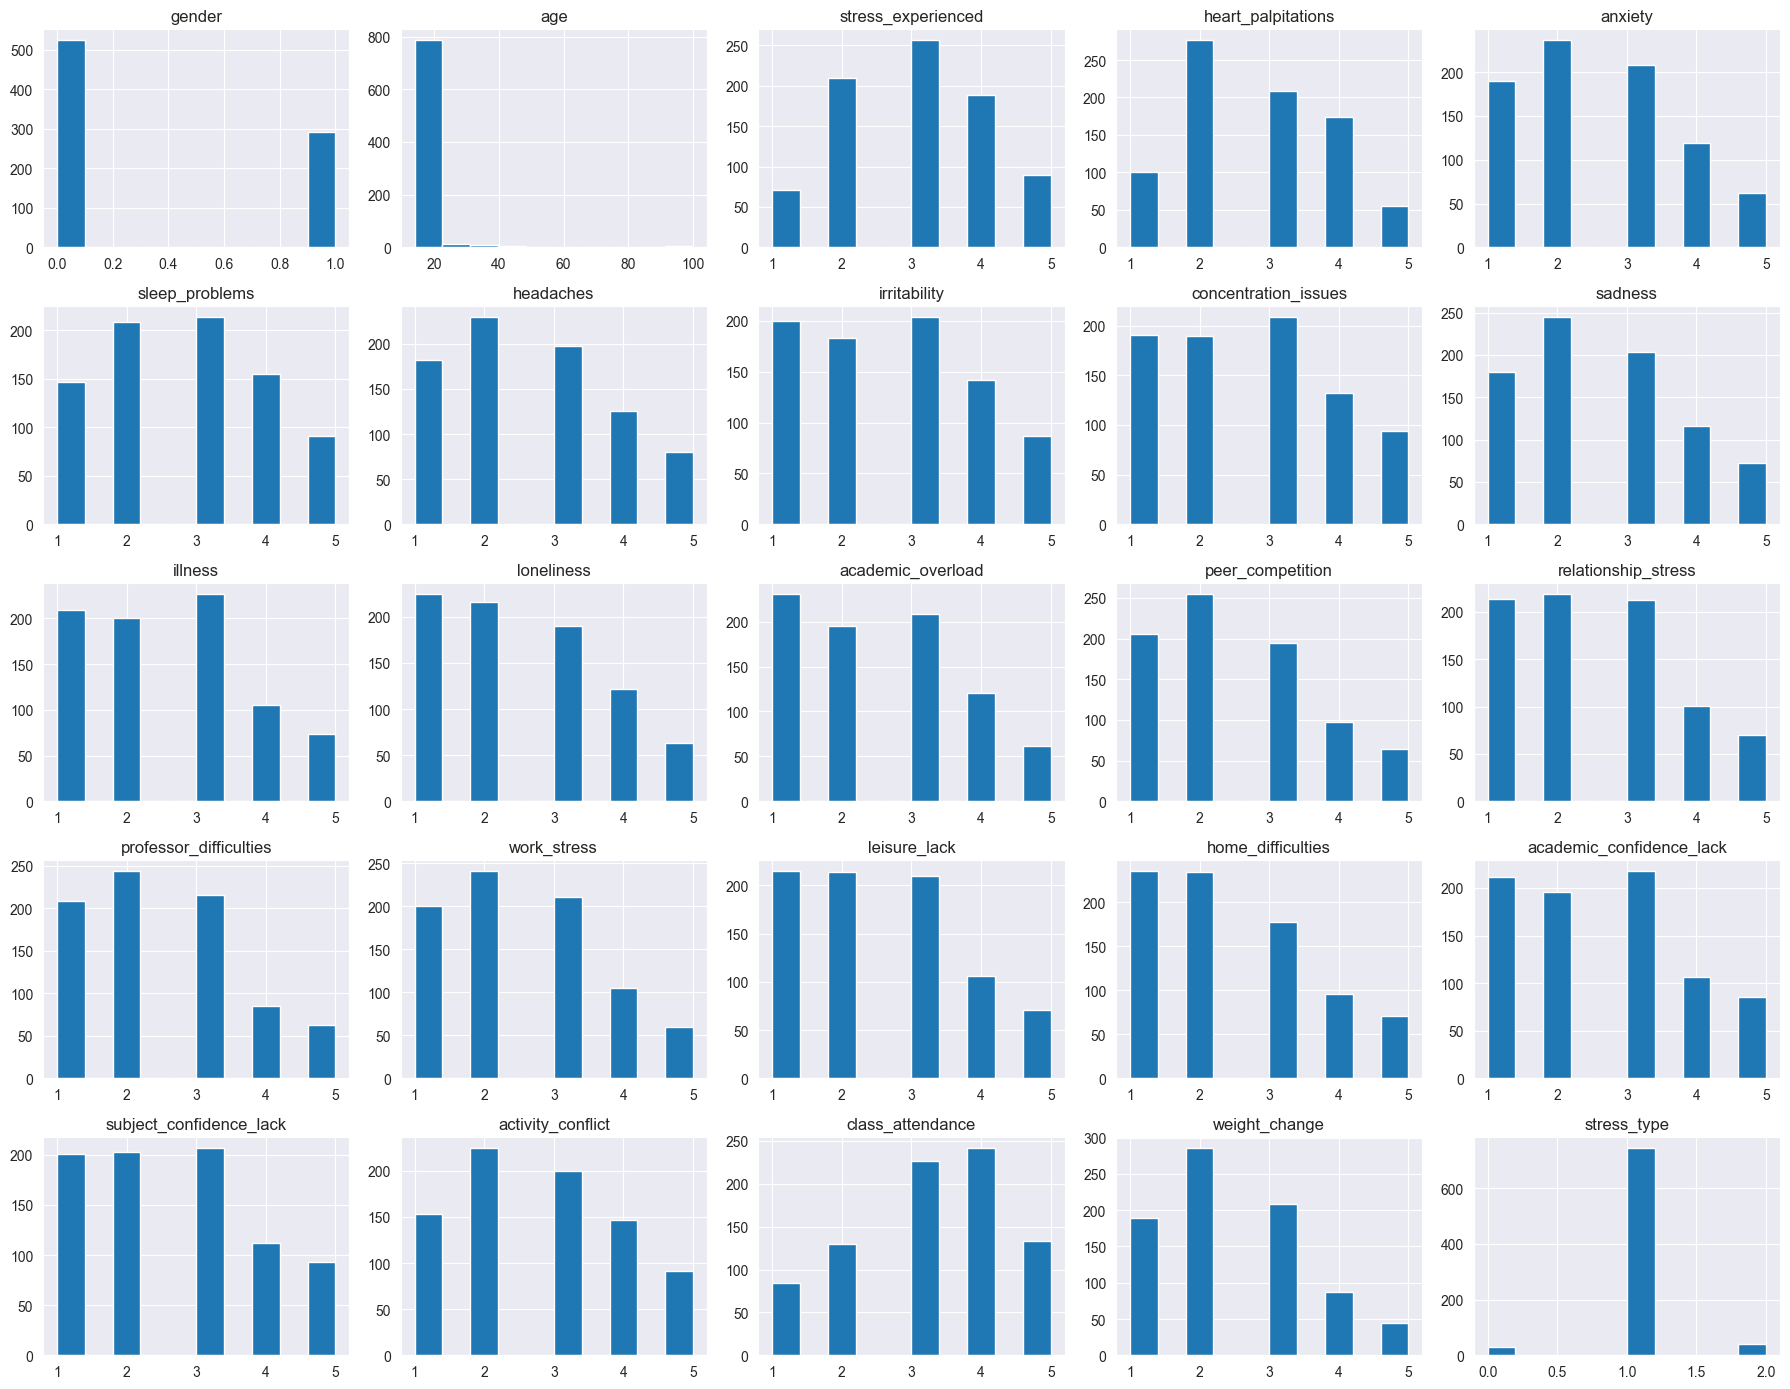

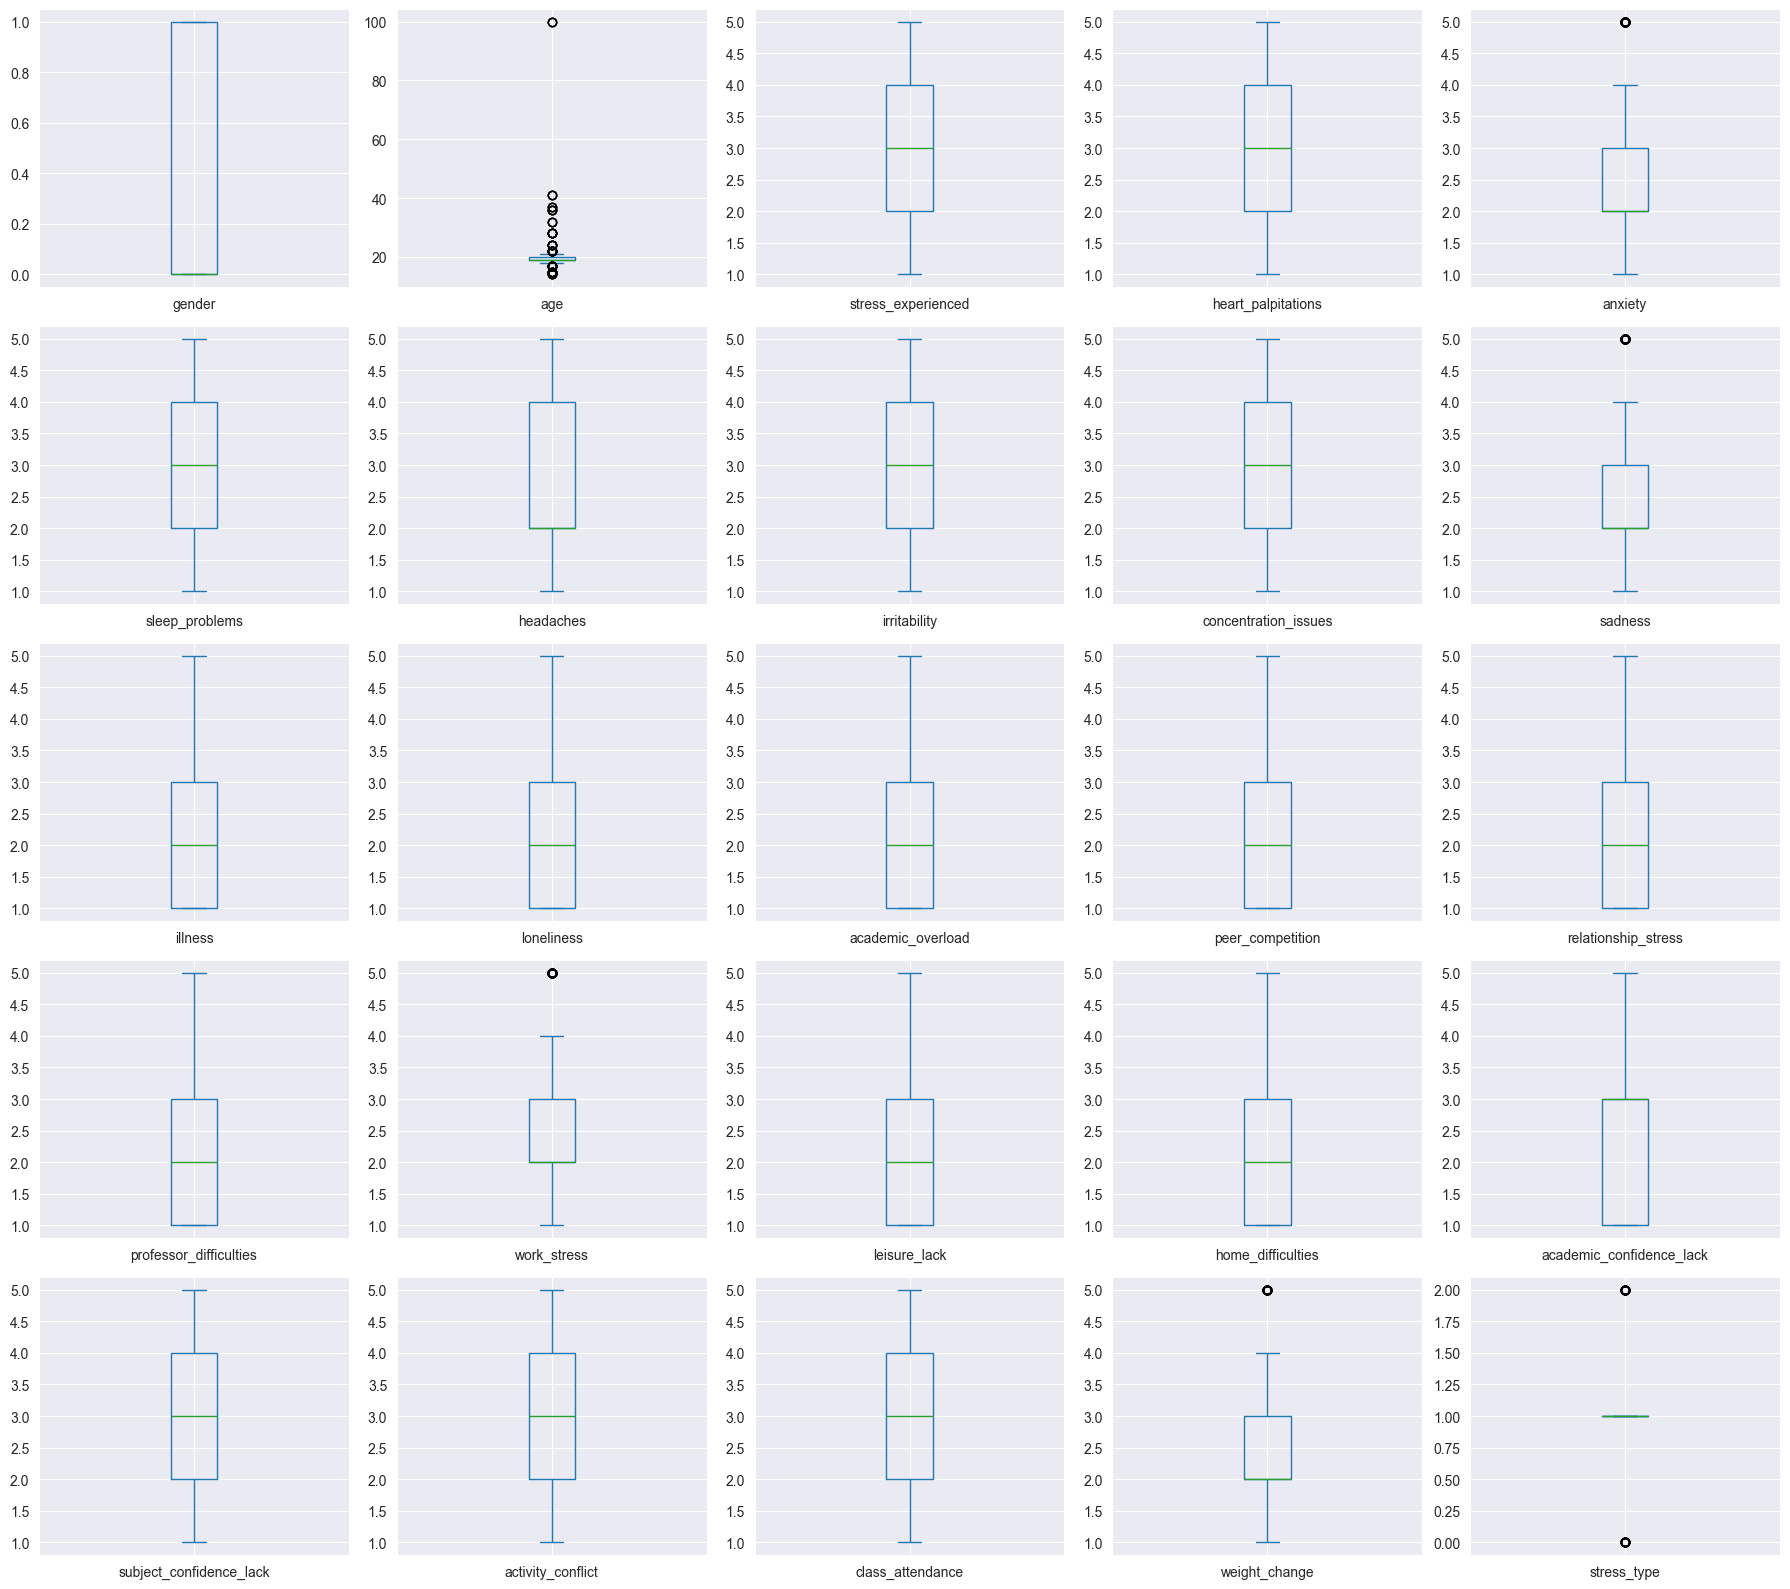

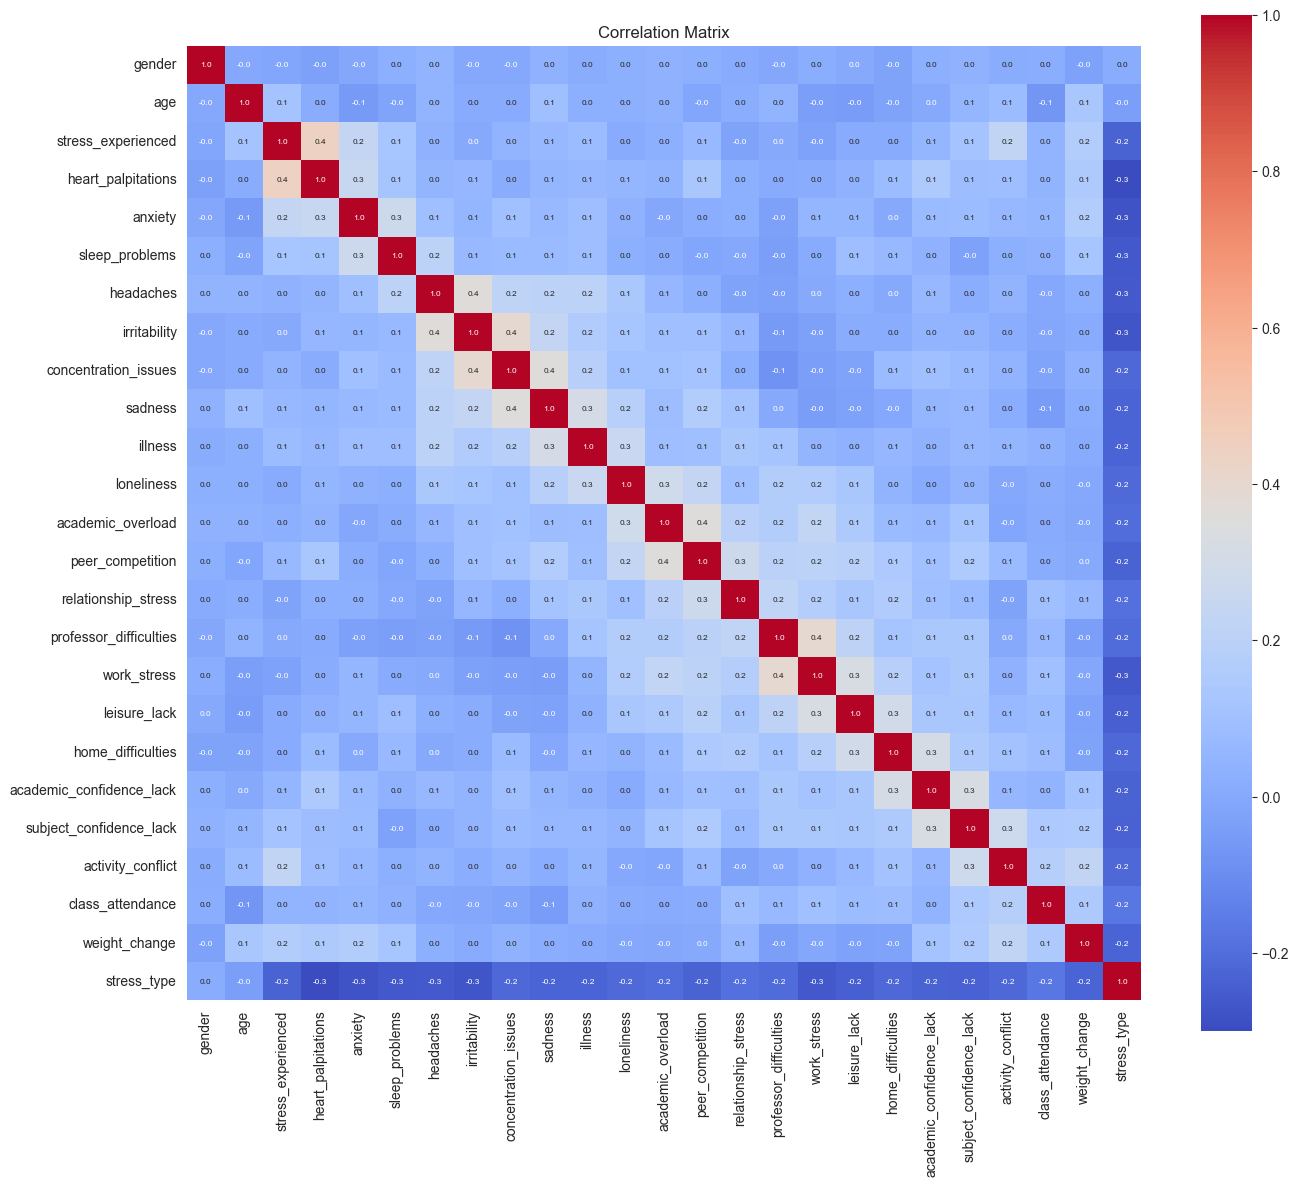

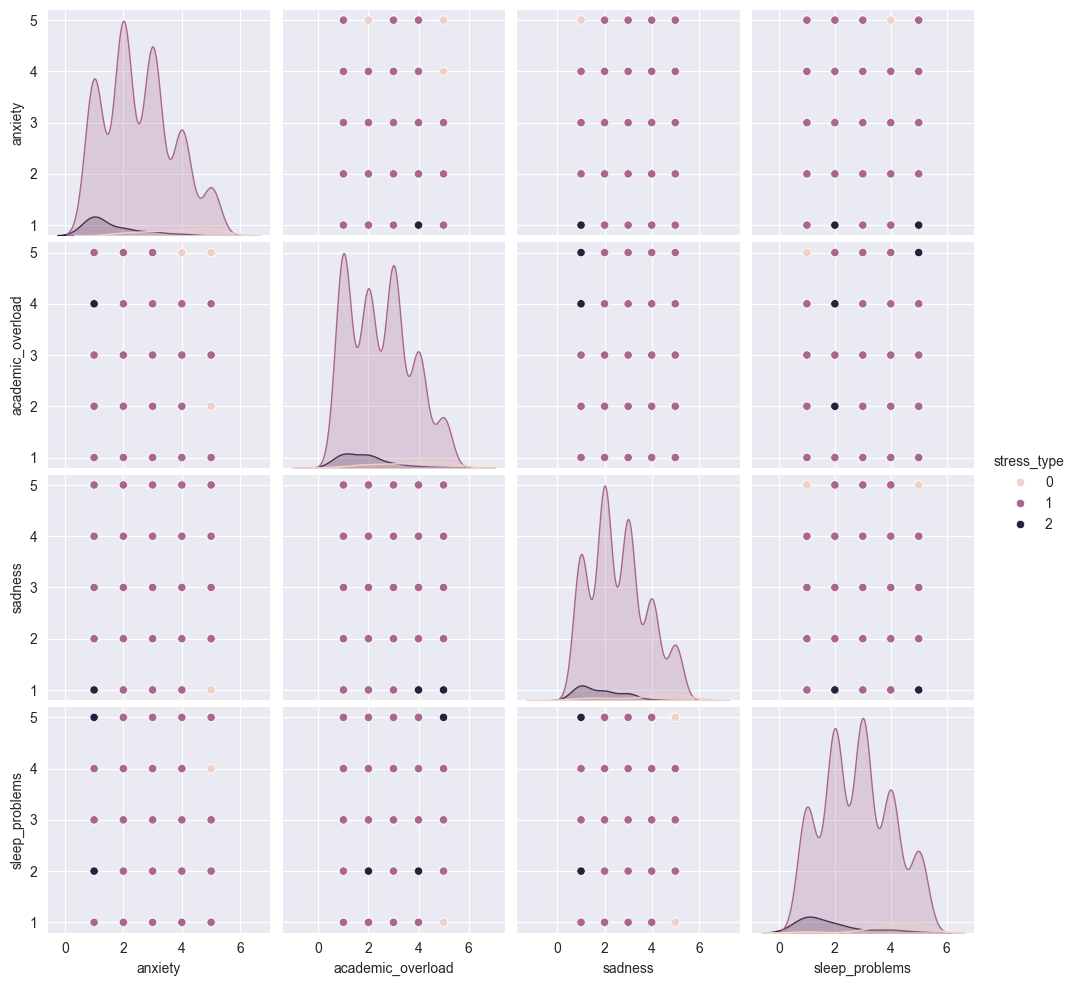

                               mean  mode  median       std    Q1    Q3
gender                     0.356618     0     0.0  0.479294   0.0   1.0
age                       20.080882    19    19.0  5.513025  19.0  20.0
stress_experienced         3.018382     3     3.0  1.128941   2.0   4.0
heart_palpitations         2.761029     2     3.0  1.123317   2.0   4.0
anxiety                    2.541667     2     2.0  1.209666   2.0   3.0
sleep_problems             2.796569     3     3.0  1.254308   2.0   4.0
headaches                  2.622549     2     2.0  1.257003   2.0   4.0
irritability               2.672794     3     3.0  1.303904   2.0   4.0
concentration_issues       2.691176     3     3.0  1.303218   2.0   4.0
sadness                    2.577206     2     2.0  1.225063   2.0   3.0
illness                    2.551471     3     2.0  1.250197   1.0   3.0
loneliness                 2.487745     1     2.0  1.251197   1.0   3.0
academic_overload          2.492647     1     2.0  1.250254   1.

,gender,age,anxiety,sleep_problems,academic_overload,stress_type
0,0,20,2,5,5,1
1,0,20,2,1,1,1
2,0,20,2,2,4,1
3,1,20,3,2,1,1
4,0,20,3,2,1,1
5,0,20,3,2,2,1
6,0,20,1,4,1,1


In [7]:
df = pd.read_csv("Stress_Dataset.csv")

col_rename = {
    "Gender": "gender",
    "Age": "age",
    "Have you recently experienced stress in your life?": "stress_experienced",
    "Have you noticed a rapid heartbeat or palpitations?": "heart_palpitations",
    "Have you been dealing with anxiety or tension recently?": "anxiety",
    "Do you face any sleep problems or difficulties falling asleep?": "sleep_problems",
    "Have you been dealing with anxiety or tension recently?.1": "anxiety_dup",
    "Have you been getting headaches more often than usual?": "headaches",
    "Do you get irritated easily?": "irritability",
    "Do you have trouble concentrating on your academic tasks?": "concentration_issues",
    "Have you been feeling sadness or low mood?": "sadness",
    "Have you been experiencing any illness or health issues?": "illness",
    "Do you often feel lonely or isolated?": "loneliness",
    "Do you feel overwhelmed with your academic workload?": "academic_overload",
    "Are you in competition with your peers, and does it affect you?": "peer_competition",
    "Do you find that your relationship often causes you stress?": "relationship_stress",
    "Are you facing any difficulties with your professors or instructors?": "professor_difficulties",
    "Is your working environment unpleasant or stressful?": "work_stress",
    "Do you struggle to find time for relaxation and leisure activities?": "leisure_lack",
    "Is your hostel or home environment causing you difficulties?": "home_difficulties",
    "Do you lack confidence in your academic performance?": "academic_confidence_lack",
    "Do you lack confidence in your choice of academic subjects?": "subject_confidence_lack",
    "Academic and extracurricular activities conflicting for you?": "activity_conflict",
    "Do you attend classes regularly?": "class_attendance",
    "Have you gained/lost weight?": "weight_change",
    "Which type of stress do you primarily experience?": "stress_type",
}
df.rename(columns=col_rename, inplace=True)
df.drop(columns=["anxiety_dup"], inplace=True)

# Simplify target labels
df["stress_type"] = df["stress_type"].str.extract(r"^(\w+)")

# Basic info
print(df.shape)
print(df.head(7))
print(df.info())
print(df.describe().T)

# Missing & duplicates
print("Missing:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.shape)

# Encode target
df["stress_type"] = LabelEncoder().fit_transform(df["stress_type"])
# 0=Distress, 1=Eustress, 2=No

# Class balance
print(df["stress_type"].value_counts())
df["stress_type"].value_counts().plot(kind="bar")
plt.title("Stress Type Distribution")
plt.xlabel("Stress Type (0=Distress, 1=Eustress, 2=No Stress)")
plt.tight_layout()
plt.show()

# Histograms
df.hist(figsize=(18, 14), bins=10)
plt.tight_layout()
plt.show()

# Boxplots
df.plot(kind="box", subplots=True, layout=(5, 5), figsize=(18, 16))
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".1f", cmap="coolwarm", square=True, annot_kws={"size": 6})
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Pairplot
sns.pairplot(df[["anxiety", "academic_overload", "sadness", "sleep_problems", "stress_type"]], hue="stress_type")
plt.show()

# Statistics
num_cols = df.select_dtypes(include=np.number).columns
stats = pd.DataFrame({
    "mean": df[num_cols].mean(),
    "mode": df[num_cols].mode().iloc[0],
    "median": df[num_cols].median(),
    "std": df[num_cols].std(),
    "Q1": df[num_cols].quantile(0.25),
    "Q3": df[num_cols].quantile(0.75)
})
print(stats)


df.drop(columns=["subject_confidence_lack"], inplace=True)
df.to_csv("Stress_Dataset_cleaned.csv", index=False)
print("Done. Saved Stress_Dataset_cleaned.csv")


df[["gender", "age", "anxiety", "sleep_problems", "academic_overload", "stress_type"]].head(7)


Total: 816 | Training: 571 (70.0%) | Test: 245 (30.0%)

Train class counts and %:
  Class 1: 519 (90.9%)
  Class 2: 29 (5.1%)
  Class 0: 23 (4.0%)

Test class counts and %:
  Class 1: 226 (92.2%)
  Class 2: 13 (5.3%)
  Class 0: 6 (2.4%)

=== RANDOM FOREST ===

Experiment 1: {'n_estimators': 50, 'max_depth': 5}
  Train: 0.9947 | Test: 0.9388 | Overfit: Yes
              precision    recall  f1-score   support

           0       0.60      0.50      0.55         6
           1       0.95      0.98      0.97       226
           2       0.71      0.38      0.50        13

    accuracy                           0.94       245
   macro avg       0.76      0.62      0.67       245
weighted avg       0.93      0.94      0.93       245



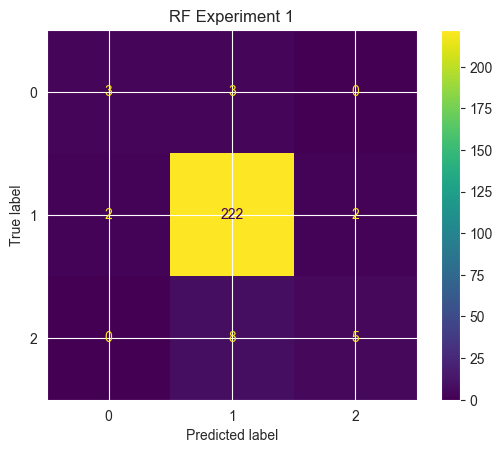


Experiment 2: {'n_estimators': 100, 'max_depth': 10}
  Train: 1.0000 | Test: 0.9347 | Overfit: Yes
              precision    recall  f1-score   support

           0       0.75      0.50      0.60         6
           1       0.94      1.00      0.97       226
           2       1.00      0.08      0.14        13

    accuracy                           0.93       245
   macro avg       0.90      0.52      0.57       245
weighted avg       0.94      0.93      0.91       245



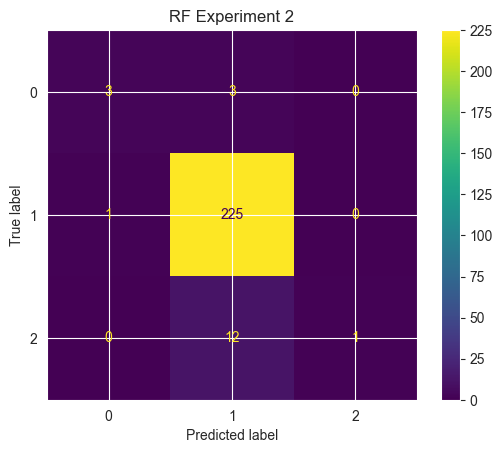


Experiment 3: {'n_estimators': 200, 'max_depth': None}
  Train: 1.0000 | Test: 0.9388 | Overfit: Yes
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.94      1.00      0.97       226
           2       1.00      0.08      0.14        13

    accuracy                           0.94       245
   macro avg       0.98      0.53      0.59       245
weighted avg       0.94      0.94      0.92       245



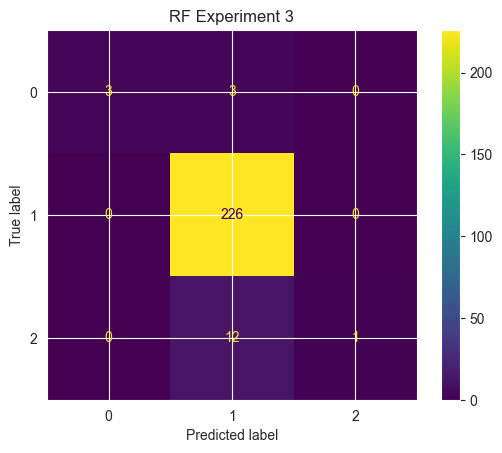


=== DECISION TREE ===

Experiment 1: {'max_depth': 3}
  Train: 0.7478 | Test: 0.7347 | Overfit: No
              precision    recall  f1-score   support

           0       0.12      0.83      0.20         6
           1       0.96      0.74      0.84       226
           2       0.26      0.54      0.35        13

    accuracy                           0.73       245
   macro avg       0.45      0.71      0.46       245
weighted avg       0.90      0.73      0.80       245



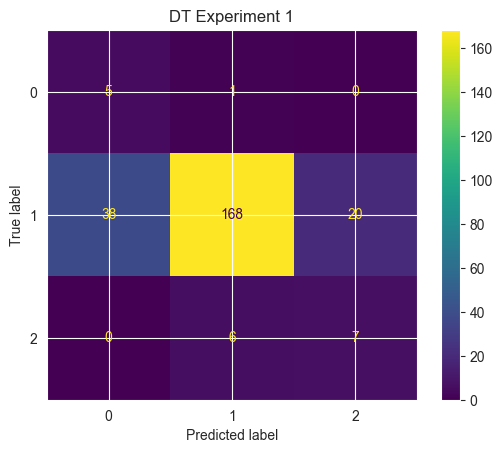


Experiment 2: {'max_depth': 5}
  Train: 0.8004 | Test: 0.7184 | Overfit: Yes
              precision    recall  f1-score   support

           0       0.25      0.67      0.36         6
           1       0.95      0.73      0.83       226
           2       0.12      0.54      0.20        13

    accuracy                           0.72       245
   macro avg       0.44      0.65      0.46       245
weighted avg       0.89      0.72      0.78       245



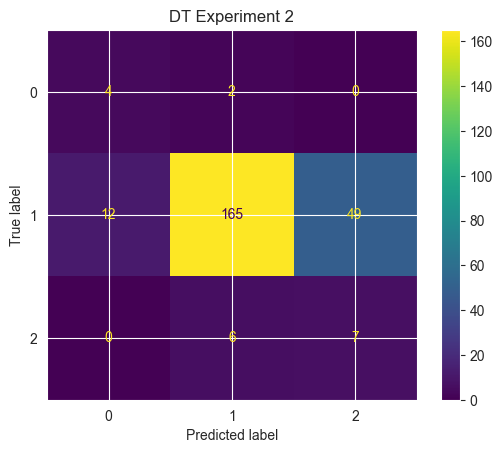


Experiment 3: {'max_depth': 10}
  Train: 0.9615 | Test: 0.8816 | Overfit: Yes
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         6
           1       0.95      0.92      0.93       226
           2       0.32      0.46      0.38        13

    accuracy                           0.88       245
   macro avg       0.53      0.63      0.57       245
weighted avg       0.90      0.88      0.89       245



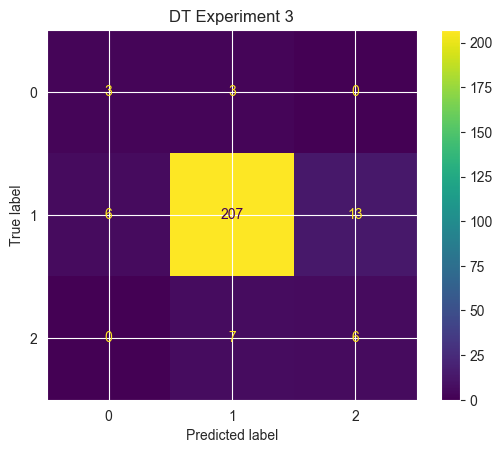

C:\Users\Abdullahi Mahamud\PycharmProjects\machine-learning\.venv\Lib\site-packages\sklearn\inspection\_plot\decision_boundary.py:225: UserWarning: 'cmap' is ignored in favor of 'multiclass_colors' in the multiclass case when the response method is 'decision_function' or 'predict_proba'.
  warnings.warn(


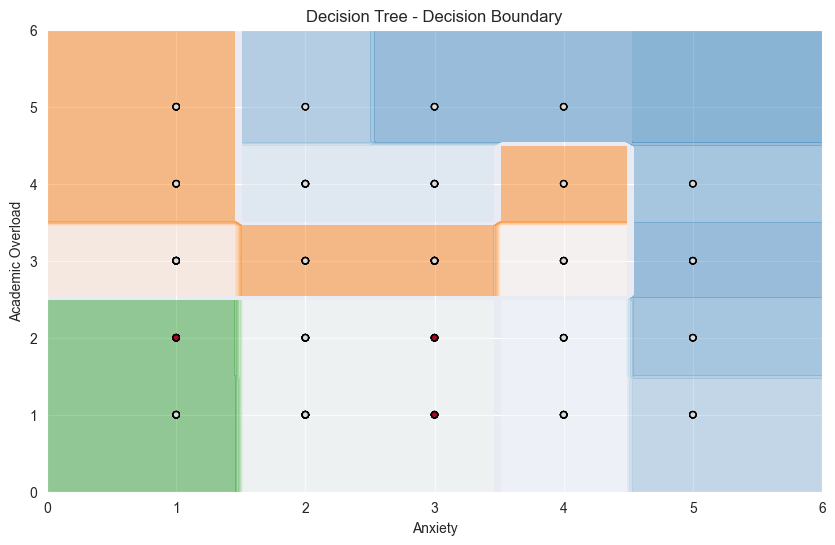

In [3]:
df = pd.read_csv("Stress_Dataset_cleaned.csv")
X = df.drop(columns=["stress_type"])
y = df["stress_type"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

total = len(y)
print(f"Total: {total} | Training: {X_train.shape[0]} ({X_train.shape[0]/total*100:.1f}%) | Test: {X_test.shape[0]} ({X_test.shape[0]/total*100:.1f}%)")
print("\nTrain class counts and %:")
for cls, cnt in y_train.value_counts().items():
    print(f"  Class {cls}: {cnt} ({cnt/len(y_train)*100:.1f}%)")
print("\nTest class counts and %:")
for cls, cnt in y_test.value_counts().items():
    print(f"  Class {cls}: {cnt} ({cnt/len(y_test)*100:.1f}%)")


print("\n=== RANDOM FOREST ===")
rf_configs = [
    {"n_estimators": 50, "max_depth": 5},
    {"n_estimators": 100, "max_depth": 10},
    {"n_estimators": 200, "max_depth": None},
]
for i, params in enumerate(rf_configs, 1):
    rf = RandomForestClassifier(**params, random_state=42, class_weight="balanced")
    rf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, rf.predict(X_train))
    test_acc = accuracy_score(y_test, rf.predict(X_test))
    print(f"\nExperiment {i}: {params}")
    print(f"  Train: {train_acc:.4f} | Test: {test_acc:.4f} | Overfit: {'Yes' if train_acc - test_acc > 0.05 else 'No'}")
    print(classification_report(y_test, rf.predict(X_test)))
    ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
    plt.title(f"RF Experiment {i}")
    plt.show()


print("\n=== DECISION TREE ===")
dt_configs = [
    {"max_depth": 3},
    {"max_depth": 5},
    {"max_depth": 10},
]
for i, params in enumerate(dt_configs, 1):
    dt = DecisionTreeClassifier(**params, random_state=42, class_weight="balanced")
    dt.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc = accuracy_score(y_test, dt.predict(X_test))
    print(f"\nExperiment {i}: {params}")
    print(f"  Train: {train_acc:.4f} | Test: {test_acc:.4f} | Overfit: {'Yes' if train_acc - test_acc > 0.05 else 'No'}")
    print(classification_report(y_test, dt.predict(X_test)))
    ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test)
    plt.title(f"DT Experiment {i}")
    plt.show()


X_train_2d = X_train[["anxiety", "academic_overload"]]
X_test_2d = X_test[["anxiety", "academic_overload"]]
dt2 = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced")
dt2.fit(X_train_2d, y_train)
fig, ax = plt.subplots(figsize=(10, 6))
DecisionBoundaryDisplay.from_estimator(dt2, X_test_2d, ax=ax, cmap="coolwarm", alpha=0.5)
ax.scatter(X_test_2d["anxiety"], X_test_2d["academic_overload"], c=y_test, cmap="coolwarm", edgecolors="k", s=20)
ax.set_xlabel("Anxiety")
ax.set_ylabel("Academic Overload")
ax.set_title("Decision Tree - Decision Boundary")
plt.show()


=== K-MEANS ===
k=2 | Silhouette Score: 0.1118
k=3 | Silhouette Score: 0.0937
k=4 | Silhouette Score: 0.0874
k=5 | Silhouette Score: 0.0651
k=6 | Silhouette Score: 0.0610


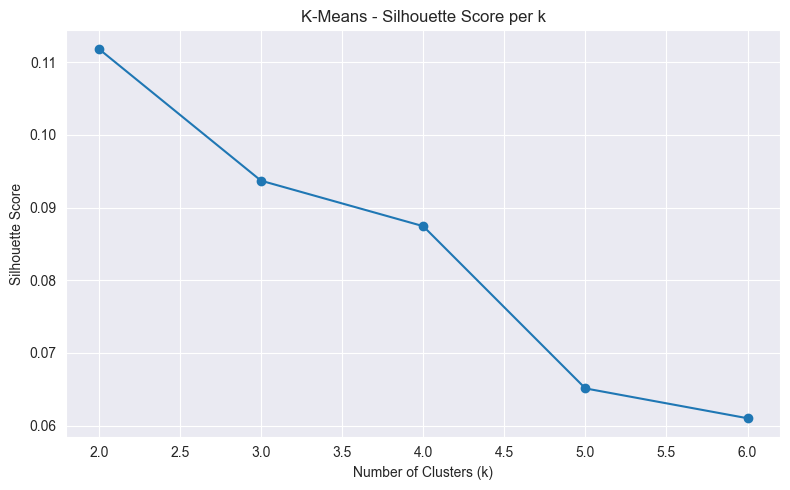


Best k: 2 (score: 0.1118)


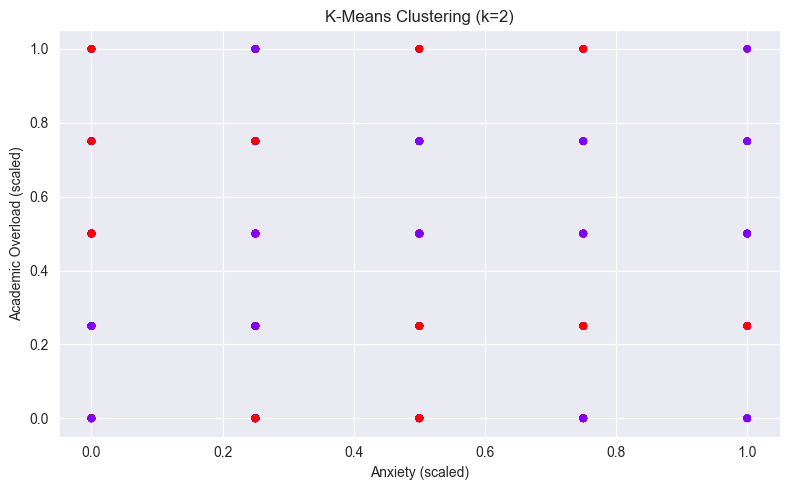


=== HIERARCHICAL CLUSTERING ===


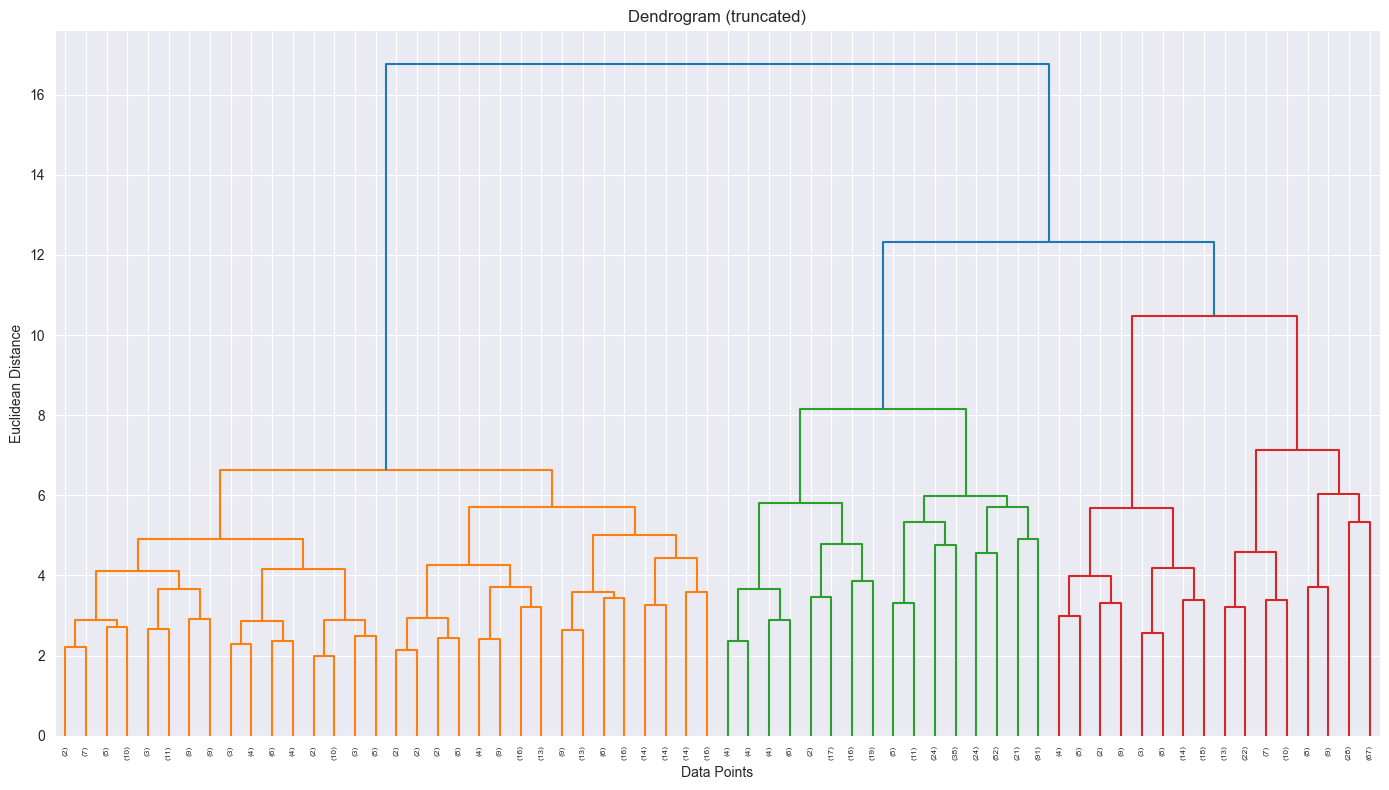


Experiment 1: {'n_clusters': 2, 'linkage': 'ward'}
  Silhouette Score: 0.0803


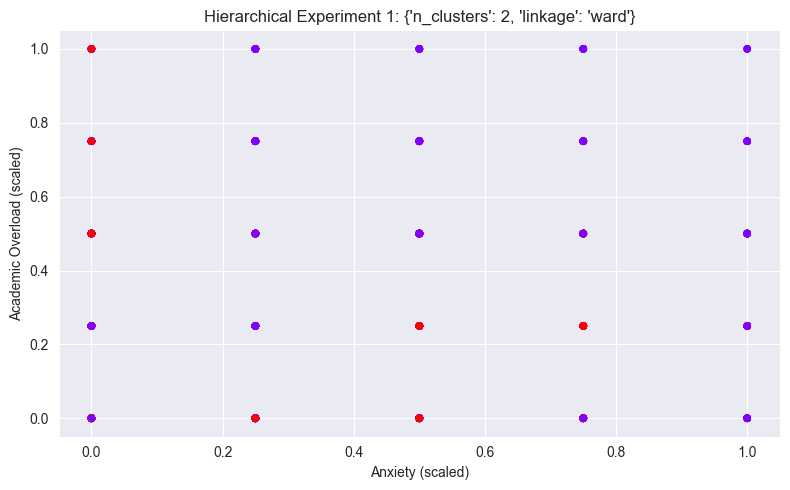


Experiment 2: {'n_clusters': 3, 'linkage': 'ward'}
  Silhouette Score: 0.0690


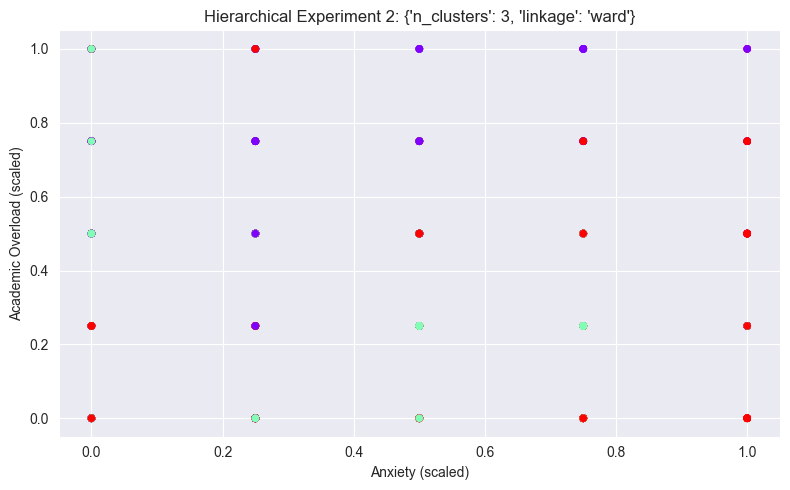


Experiment 3: {'n_clusters': 3, 'linkage': 'complete'}
  Silhouette Score: 0.0902


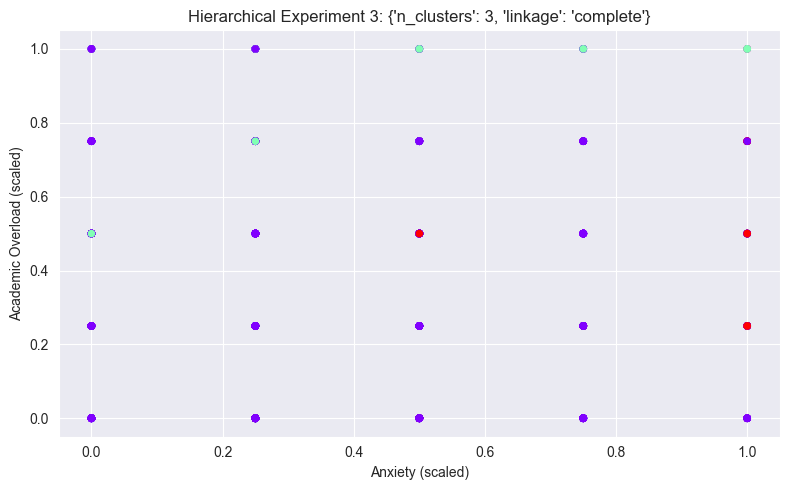

In [4]:
df = pd.read_csv("Stress_Dataset_cleaned.csv")
X_raw = df.drop(columns=["stress_type"])


scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns)


print("=== K-MEANS ===")
k_values = [2, 3, 4, 5, 6]
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"k={k} | Silhouette Score: {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means - Silhouette Score per k")
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(silhouette_scores)]
print(f"\nBest k: {best_k} (score: {max(silhouette_scores):.4f})")

kmeans_best = KMeans(n_clusters=best_k, init="k-means++", random_state=42)
labels_best = kmeans_best.fit_predict(X)
plt.figure(figsize=(8, 5))
plt.scatter(X["anxiety"], X["academic_overload"], c=labels_best, cmap="rainbow", s=20)
plt.xlabel("Anxiety (scaled)")
plt.ylabel("Academic Overload (scaled)")
plt.title(f"K-Means Clustering (k={best_k})")
plt.tight_layout()
plt.show()


print("\n=== HIERARCHICAL CLUSTERING ===")

plt.figure(figsize=(14, 8))
plt.title("Dendrogram (truncated)")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
shc.dendrogram(shc.linkage(X, method="ward"), truncate_mode="level", p=5)
plt.tight_layout()
plt.show()

hc_configs = [
    {"n_clusters": 2, "linkage": "ward"},
    {"n_clusters": 3, "linkage": "ward"},
    {"n_clusters": 3, "linkage": "complete"},
]
for i, params in enumerate(hc_configs, 1):
    hc = AgglomerativeClustering(**params)
    labels = hc.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"\nExperiment {i}: {params}")
    print(f"  Silhouette Score: {score:.4f}")
    plt.figure(figsize=(8, 5))
    plt.scatter(X["anxiety"], X["academic_overload"], c=labels, cmap="rainbow", s=20)
    plt.xlabel("Anxiety (scaled)")
    plt.ylabel("Academic Overload (scaled)")
    plt.title(f"Hierarchical Experiment {i}: {params}")
    plt.tight_layout()
    plt.show()
